# FairCare Raw Diabetes Dataset Explanation

This notebook explains the raw diabetes readmission dataset used in the FairCare project. The goal is to understand the dataset, target variable, selected features, and feature groups before running machine learning experiments.

**Key Concept:**  
FairCare predicts whether a diabetic patient will be readmitted within 30 days.


# SECTION 2: Load Raw Dataset

We load the raw diabetes dataset from `diabetic_data.csv`. We display key exploratory statistics:
- Dataset shape (rows, columns)
- Total rows and columns
- Column names
- First 5 rows
- Basic schema info (`df.info()`)
- Missing value summary (standard pandas `NaN`)

*Note: No full cleaning is performed. This notebook is strictly for exploratory explanation.*


In [1]:
import pandas as pd
import numpy as np

# Load raw dataset
df = pd.read_csv('diabetic_data.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\nColumn Names:")
print(list(df.columns))
print("\nFirst 5 Rows:")
display(df.head())
print("\nBasic Info:")
df.info()
print("\nMissing Value Summary (standard pandas NaN):")
nan_summary = df.isna().sum()
display(nan_summary[nan_summary > 0])


Dataset Shape: (101766, 50)
Number of Rows: 101766
Number of Columns: 50

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

First 5 Rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int

max_glu_serum    96420
A1Cresult        84748
dtype: int64

# SECTION 3: Target Variable Explanation

The target column in this dataset is `readmitted`.
Originally, the column contains three possible values:
- `<30`: Patient was readmitted within 30 days.
- `>30`: Patient was readmitted after 30 days.
- `NO`: Patient was not readmitted.

### Binarization Schema
In the FairCare project, we formulate this as a binary classification problem focusing strictly on 30-day readmissions:

| Original value | Binary class | Meaning |
|---|---:|---|
| <30 | 1 | Readmitted within 30 days |
| >30 | 0 | Readmitted after 30 days, treated as not 30-day readmission |
| NO | 0 | Not readmitted |

### Class Meaning Table
The binarized labels represent the following clinical classes:

| Class | Meaning | Importance |
|---|---|---|
| Class 0 | Not readmitted within 30 days | Negative class |
| Class 1 | Readmitted within 30 days | Clinically important class |

**Clinical Significance:**  
Class 1 is the main healthcare class because it represents patients who came back to the hospital within 30 days. Hospital readmissions within 30 days are heavily monitored quality-of-care indicators, often linked to financial penalties and adverse patient outcomes.

We display the real, un-cleansed distributions of the original target and binarized target below.


In [2]:
# Original target distribution
print("Original 'readmitted' distribution:")
orig_counts = df['readmitted'].value_counts()
orig_pct = df['readmitted'].value_counts(normalize=True) * 100
orig_df = pd.DataFrame({'Count': orig_counts, 'Percentage (%)': orig_pct})
display(orig_df)

# Binarize readmitted target
# Class 1 = Readmitted within 30 days (<30)
# Class 0 = Readmitted after 30 days (>30) or Not readmitted (NO)
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("\nBinarized class distribution:")
bin_counts = df['readmitted_binary'].value_counts()
bin_pct = df['readmitted_binary'].value_counts(normalize=True) * 100
bin_df = pd.DataFrame({'Count': bin_counts, 'Percentage (%)': bin_pct})
bin_df.index = bin_df.index.map({0: 'Class 0 (Not readmitted within 30 days)', 1: 'Class 1 (Readmitted within 30 days)'})
display(bin_df)


Original 'readmitted' distribution:


,Count,Percentage (%)
readmitted,,
NO,54864,53.911916
>30,35545,34.928169
<30,11357,11.159916



Binarized class distribution:


,Count,Percentage (%)
readmitted_binary,,
Class 0 (Not readmitted within 30 days),90409,88.840084
Class 1 (Readmitted within 30 days),11357,11.159916


# SECTION 4: Selected Features Used in FairCare

The FairCare project uses only these **18 selected features**:
1. `number_inpatient`
2. `time_in_hospital`
3. `number_emergency`
4. `number_outpatient`
5. `num_medications`
6. `num_lab_procedures`
7. `diabetesMed`
8. `insulin`
9. `metformin`
10. `admission_type_id`
11. `discharge_disposition_id`
12. `max_glu_serum`
13. `A1Cresult`
14. `race`
15. `age`
16. `diag_1`
17. `diag_2`
18. `gender`

### Feature Mapping and Categories Table
The selected features are organized into 5 logical, clinically relevant categories:

| Feature | Category | Simple meaning | Why it may matter |
|---|---|---|---|
| **number_inpatient** | Prior visit features | Number of inpatient visits in the preceding year | Suggests chronic health issues and frequent intensive healthcare usage |
| **number_emergency** | Prior visit features | Number of emergency department visits in the preceding year | Reflects acute crisis episodes and potential lack of stable outpatient care |
| **number_outpatient** | Prior visit features | Number of outpatient clinic visits in the preceding year | Indicates routine management, chronic disease maintenance, or preventive care |
| **time_in_hospital** | Hospital stay / admission features | Number of days spent in the hospital during the current stay | Directly represents acute illness severity and resource intensity |
| **admission_type_id** | Hospital stay / admission features | Integer ID representing how the patient entered (Emergency, Urgent, etc.) | Distinguishes scheduled elective admissions from high-risk unplanned crises |
| **discharge_disposition_id** | Hospital stay / admission features | Integer ID indicating where the patient went after discharge | Essential marker for safety; discharge to home vs. nursing home/hospice dramatically affects readmission likelihood |
| **num_medications** | Medication and lab features | Number of unique generic medications prescribed | Reflects disease burden, treatment complexity, and polypharmacy risks |
| **num_lab_procedures** | Medication and lab features | Number of laboratory tests ordered during the stay | Indicates diagnostic intensity, clinical uncertainty, or metabolic instability |
| **diabetesMed** | Medication and lab features | Binary flag indicating if any diabetes medication was prescribed | Confirms active pharmacological management of diabetes during the encounter |
| **insulin** | Medication and lab features | Insulin status (No, Down, Up, Steady) | Key advanced medication; modifications signal glycemic instability or change in severity |
| **metformin** | Medication and lab features | Metformin status (No, Down, Up, Steady) | Standard first-line oral diabetes agent; indicates baseline type-2 management |
| **max_glu_serum** | Medication and lab features | Results of glucose serum test (None, >200, >300, Norm) | Measures acute blood sugar spikes; high levels show immediate uncontrolled hyperglycemia |
| **A1Cresult** | Medication and lab features | Results of A1C test (None, >7, >8, Norm) | Measures long-term blood sugar control (average over the preceding 2-3 months) |
| **diag_1** | Diagnosis features | Primary diagnosis code (ICD-9 classification) | The primary acute condition responsible for the current hospital stay |
| **diag_2** | Diagnosis features | Secondary diagnosis code (ICD-9 classification) | Principal secondary comorbidity contributing to clinical complexity |
| **race** | Demographic features | Self-reported racial/ethnic category | Essential demographic group used for clinical equity and fairness slicing |
| **age** | Demographic features | 10-year age decile intervals (e.g. `[70-80)`) | Strong risk driver due to geriatric vulnerabilities and Medicare eligibility |
| **gender** | Demographic features | Self-reported biological gender (Female, Male) | Crucial for studying gender disparities in clinical care and model performance |


# SECTION 5: Feature Group Explanation

We now analyze each of the 5 feature groups in detail, printing data types, missing value statistics, and distributions from the real raw dataset.


## 5.1 Prior Visit Features

These features describe the patient’s previous hospital or emergency visits in the preceding year. More previous visits typically indicate a patient with higher clinical risk, multiple chronic conditions, or suboptimal primary care.

**Features:**
- `number_inpatient`
- `number_emergency`
- `number_outpatient`


In [3]:
prior_features = ['number_inpatient', 'number_emergency', 'number_outpatient']
for f in prior_features:
    print(f"=== Feature: {f} ===")
    print(f"Data Type: {df[f].dtype}")
    print(f"Missing Values (NaN): {df[f].isna().sum()}")
    print(f"Unknown Values ('?'): {(df[f] == '?').sum() if df[f].dtype == 'object' else 0}")
    print("\nDescriptive Statistics:")
    display(df[f].describe())
    print("-" * 50)


=== Feature: number_inpatient ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

--------------------------------------------------
=== Feature: number_emergency ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

--------------------------------------------------
=== Feature: number_outpatient ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

--------------------------------------------------


## 5.2 Hospital Stay and Admission Features

These features describe the index hospital admission itself: how the patient entered, how long they stayed, and their clinical safety discharge pathway.

**Features:**
- `time_in_hospital`
- `admission_type_id`
- `discharge_disposition_id`


In [4]:
hospital_features = ['time_in_hospital', 'admission_type_id', 'discharge_disposition_id']
for f in hospital_features:
    print(f"=== Feature: {f} ===")
    print(f"Data Type: {df[f].dtype}")
    print(f"Missing Values (NaN): {df[f].isna().sum()}")
    print(f"Unknown Values ('?'): {(df[f] == '?').sum() if df[f].dtype == 'object' else 0}")
    if f == 'time_in_hospital':
        print("\nDescriptive Statistics:")
        display(df[f].describe())
    else:
        print("\nValue Counts (Top 10):")
        display(df[f].value_counts().head(10))
    print("-" * 50)


=== Feature: time_in_hospital ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

--------------------------------------------------
=== Feature: admission_type_id ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Value Counts (Top 10):


admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

--------------------------------------------------
=== Feature: discharge_disposition_id ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Value Counts (Top 10):


discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64

--------------------------------------------------


## 5.3 Medication and Lab Features

These features capture pharmacological treatments, diagnostic test volume, and metabolic monitoring results.

**Features:**
- `num_medications`
- `num_lab_procedures`
- `diabetesMed`
- `insulin`
- `metformin`
- `max_glu_serum`
- `A1Cresult`


In [5]:
med_lab_features = ['num_medications', 'num_lab_procedures', 'diabetesMed', 'insulin', 'metformin', 'max_glu_serum', 'A1Cresult']
for f in med_lab_features:
    print(f"=== Feature: {f} ===")
    print(f"Data Type: {df[f].dtype}")
    print(f"Missing Values (NaN): {df[f].isna().sum()}")
    print(f"Unknown Values ('?'): {(df[f] == '?').sum() if df[f].dtype == 'object' else 0}")
    if df[f].dtype in ['int64', 'float64']:
        print("\nDescriptive Statistics:")
        display(df[f].describe())
    else:
        print("\nValue Counts (including NaN):")
        display(df[f].value_counts(dropna=False))
    print("-" * 50)


=== Feature: num_medications ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

--------------------------------------------------
=== Feature: num_lab_procedures ===
Data Type: int64
Missing Values (NaN): 0
Unknown Values ('?'): 0

Descriptive Statistics:


count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

--------------------------------------------------
=== Feature: diabetesMed ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 0

Value Counts (including NaN):


...

--------------------------------------------------
=== Feature: max_glu_serum ===
Data Type: object
Missing Values (NaN): 96420
Unknown Values ('?'): 0

Value Counts (including NaN):


max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

--------------------------------------------------
=== Feature: A1Cresult ===
Data Type: object
Missing Values (NaN): 84748
Unknown Values ('?'): 0

Value Counts (including NaN):


A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

--------------------------------------------------


## 5.4 Diagnosis Features

Diagnosis features specify the patient's acute illnesses and active comorbidity profile represented as ICD-9 codes. Certain primary and secondary diagnoses are historically strongly associated with readmission risks.

**Features:**
- `diag_1`
- `diag_2`


In [6]:
diag_features = ['diag_1', 'diag_2']
for f in diag_features:
    print(f"=== Feature: {f} ===")
    print(f"Data Type: {df[f].dtype}")
    print(f"Missing Values (NaN): {df[f].isna().sum()}")
    print(f"Unknown Values ('?'): {(df[f] == '?').sum() if df[f].dtype == 'object' else 0}")
    print("\nValue Counts (Top 10):")
    display(df[f].value_counts().head(10))
    print("-" * 50)


=== Feature: diag_1 ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 21

Value Counts (Top 10):


diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

--------------------------------------------------
=== Feature: diag_2 ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 358

Value Counts (Top 10):


diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

--------------------------------------------------


## 5.5 Demographic Features

Demographic features describe the social and biological identity of the patient.

**Features:**
- `race`
- `age`
- `gender`

**Demographic Fairness Relevance:**  
These demographic columns serve a dual purpose. In addition to being utilized as regular predictive features in the machine learning models, **they are also strictly reserved later as slicing variables to evaluate fairness across groups** (e.g. measuring whether models exhibit performance gaps, higher error rates, or poor calibration for minority populations, elder populations, or female/male cohorts).


In [7]:
demo_features = ['race', 'age', 'gender']
for f in demo_features:
    print(f"=== Feature: {f} ===")
    print(f"Data Type: {df[f].dtype}")
    print(f"Missing Values (NaN): {df[f].isna().sum()}")
    print(f"Unknown Values ('?'): {(df[f] == '?').sum() if df[f].dtype == 'object' else 0}")
    print("\nValue Counts (including NaN):")
    display(df[f].value_counts(dropna=False))
    print("-" * 50)


=== Feature: race ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 2273

Value Counts (including NaN):


race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--------------------------------------------------
=== Feature: age ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 0

Value Counts (including NaN):


age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--------------------------------------------------
=== Feature: gender ===
Data Type: object
Missing Values (NaN): 0
Unknown Values ('?'): 0

Value Counts (including NaN):


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--------------------------------------------------


# SECTION 6: Selected Feature Dataset Preview

We isolate a sub-dataframe containing strictly the **18 selected features** and the binarized `readmitted` target.
This selected feature dataset represents the starting foundation for all subsequent FairCare experiments.

Below, we display its dimensions, first 5 rows, basic data type structures, and missing value counts.


In [8]:
selected_features = [
    'number_inpatient', 'time_in_hospital', 'number_emergency', 'number_outpatient',
    'num_medications', 'num_lab_procedures', 'diabetesMed', 'insulin', 'metformin',
    'admission_type_id', 'discharge_disposition_id', 'max_glu_serum', 'A1Cresult',
    'race', 'age', 'diag_1', 'diag_2', 'gender'
]
selected_df = df[selected_features + ['readmitted_binary']].rename(columns={'readmitted_binary': 'readmitted'})

print(f"Selected Feature Dataset Shape: {selected_df.shape}")
print("\nFirst 5 Rows:")
display(selected_df.head())
print("\nMissing Value Summary (standard pandas NaN):")
display(selected_df.isna().sum())
print("\nData Types:")
display(selected_df.dtypes)


Selected Feature Dataset Shape: (101766, 19)

First 5 Rows:


,number_inpatient,time_in_hospital,number_emergency,number_outpatient,num_medications,num_lab_procedures,diabetesMed,insulin,metformin,admission_type_id,discharge_disposition_id,max_glu_serum,A1Cresult,race,age,diag_1,diag_2,gender,readmitted
0,0,1,0,0,1,41,No,No,No,6,25,NaN,NaN,Caucasian,[0-10),250.83,?,Female,0
1,0,3,0,0,18,59,Yes,Up,No,1,1,NaN,NaN,Caucasian,[10-20),276,250.01,Female,0
2,1,2,0,2,13,11,Yes,No,No,1,1,NaN,NaN,AfricanAmerican,[20-30),648,250,Female,0
3,0,2,0,0,16,44,Yes,Up,No,1,1,NaN,NaN,Caucasian,[30-40),8,250.43,Male,0
4,0,1,0,0,8,51,Yes,Steady,No,1,1,NaN,NaN,Caucasian,[40-50),197,157,Male,0



Missing Value Summary (standard pandas NaN):


number_inpatient                0
time_in_hospital                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_lab_procedures              0
diabetesMed                     0
insulin                         0
metformin                       0
admission_type_id               0
discharge_disposition_id        0
max_glu_serum               96420
A1Cresult                   84748
race                            0
age                             0
diag_1                          0
diag_2                          0
gender                          0
readmitted                      0
dtype: int64


Data Types:


number_inpatient             int64
time_in_hospital             int64
number_emergency             int64
number_outpatient            int64
num_medications              int64
num_lab_procedures           int64
diabetesMed                 object
insulin                     object
metformin                   object
admission_type_id            int64
discharge_disposition_id     int64
max_glu_serum               object
A1Cresult                   object
race                        object
age                         object
diag_1                      object
diag_2                      object
gender                      object
readmitted                   int64
dtype: object

# SECTION 7: Missing Values and Unknown Values

We present a complete, detailed summary of all missingness types in the 18 selected features of the raw dataset.
This includes standard `NaN` missing values (commonly resulting from 'None' strings in clinical tests) and character `'?'` placeholders representing unrecorded/unknown categories.

*Note: No data imputation or cleaning is performed here. This section strictly identifies and logs the raw missingness landscape.*


In [9]:
missing_records = []
for f in selected_features:
    col = df[f]
    nan_count = col.isna().sum()
    nan_pct = (nan_count / len(df)) * 100
    q_count = (col == '?').sum() if col.dtype == 'object' else 0
    missing_records.append({
        'Feature': f,
        'Missing Count (NaN)': nan_count,
        'Missing %': f"{nan_pct:.4f}%",
        "Unknown '?' Count": q_count
    })

missing_table_df = pd.DataFrame(missing_records)
display(missing_table_df)


,Feature,Missing Count (NaN),Missing %,Unknown '?' Count
0,number_inpatient,0,0.0000%,0
1,time_in_hospital,0,0.0000%,0
2,number_emergency,0,0.0000%,0
3,number_outpatient,0,0.0000%,0
4,num_medications,0,0.0000%,0
5,num_lab_procedures,0,0.0000%,0
6,diabetesMed,0,0.0000%,0
7,insulin,0,0.0000%,0
8,metformin,0,0.0000%,0
9,admission_type_id,0,0.0000%,0


# SECTION 8: Simple Visualizations

We generate 8 clean, descriptive exploratory plots using strictly `matplotlib` (no `seaborn`).
Each plot represents a key dataset characteristic: distribution of variables, demographic breakdowns, or clinical metrics.
Gridlines, clear axes, and a structured, highly legible style are maintained.


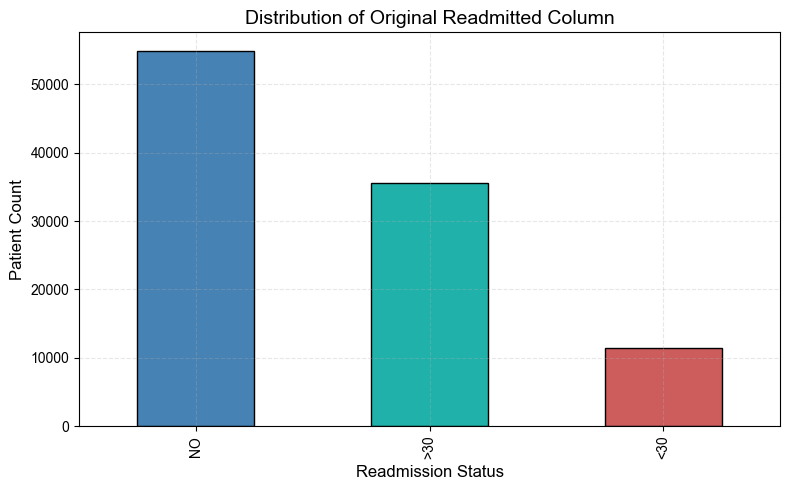

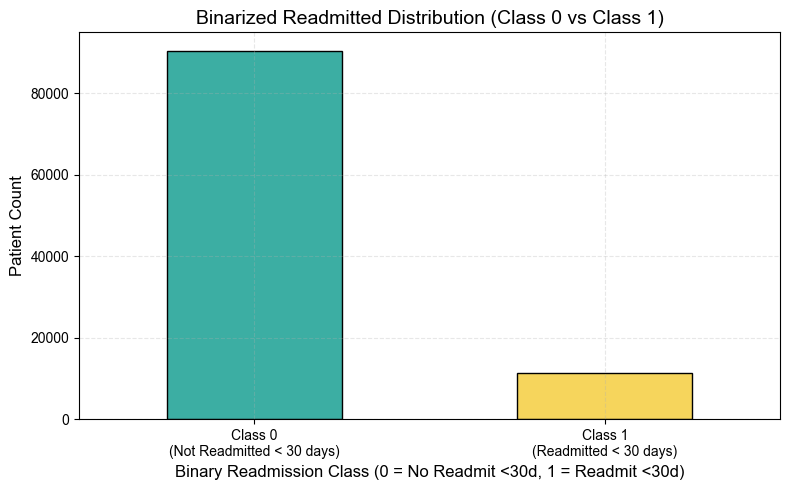

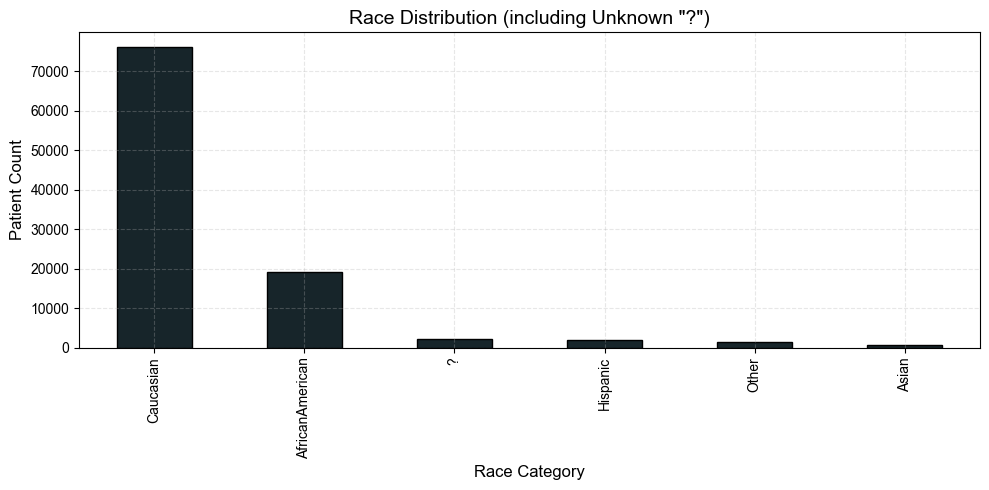

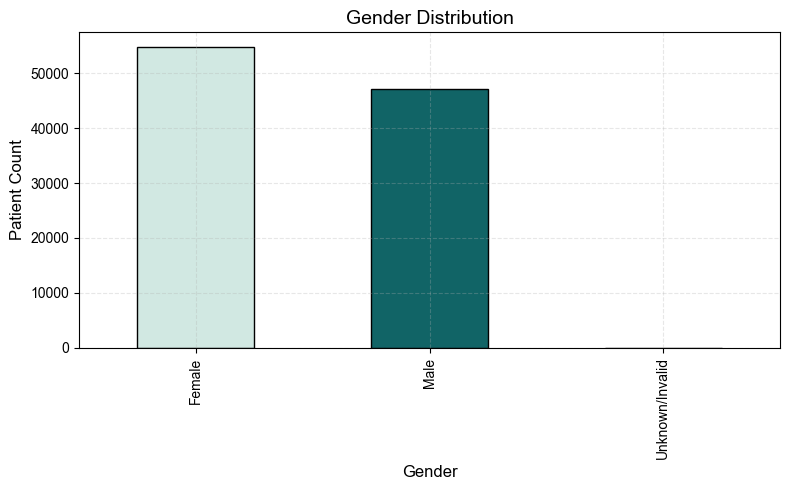

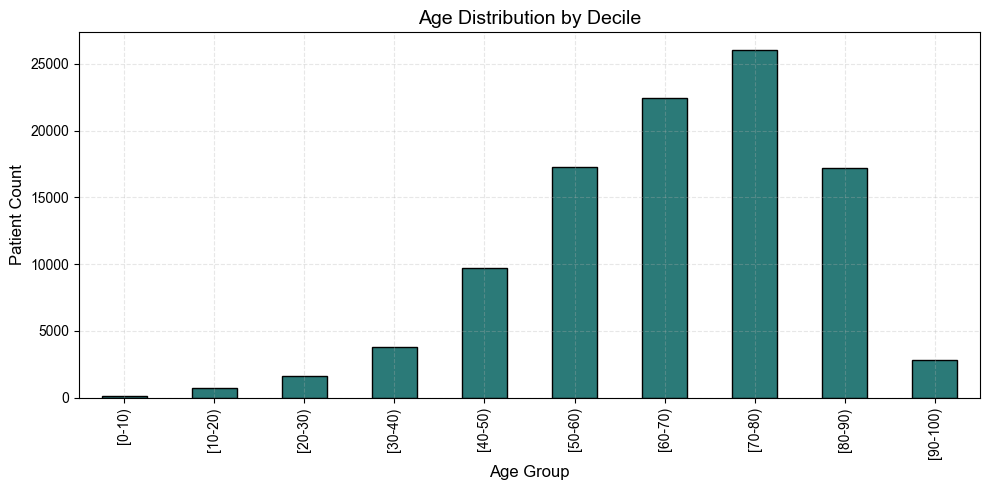

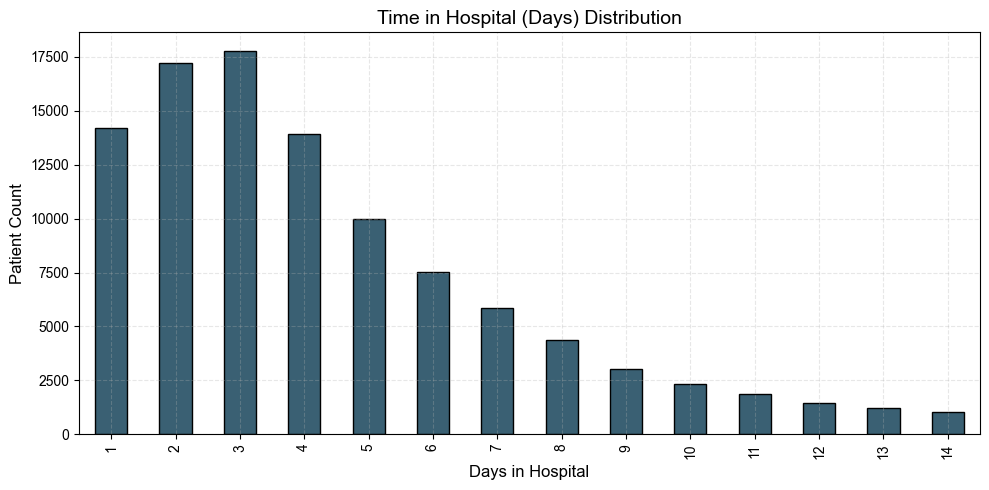

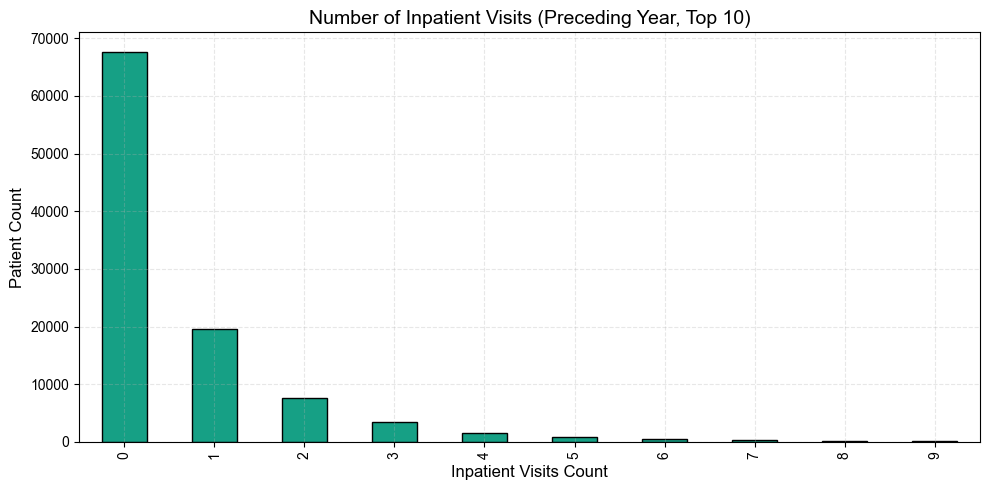

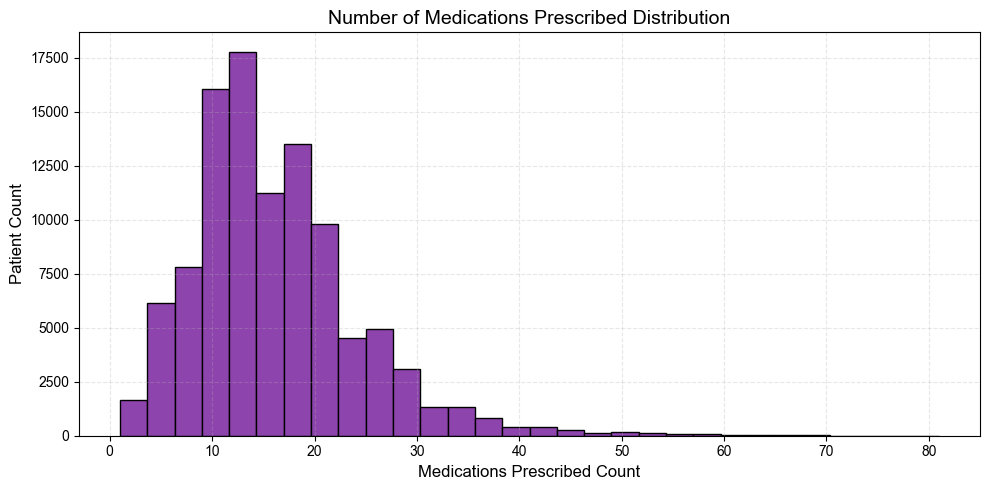

In [10]:
import matplotlib.pyplot as plt

# Styling parameters
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# 1. Target distribution: readmitted
plt.figure(figsize=(8, 5))
df['readmitted'].value_counts().plot(kind='bar', color=['#4682B4', '#20B2AA', '#CD5C5C'], edgecolor='black')
plt.title('Distribution of Original Readmitted Column')
plt.xlabel('Readmission Status')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Binary Class 0 vs Class 1 distribution
plt.figure(figsize=(8, 5))
df['readmitted_binary'].value_counts().plot(kind='bar', color=['#3CAEA3', '#F6D55C'], edgecolor='black')
plt.title('Binarized Readmitted Distribution (Class 0 vs Class 1)')
plt.xlabel('Binary Readmission Class (0 = No Readmit <30d, 1 = Readmit <30d)')
plt.ylabel('Patient Count')
plt.xticks([0, 1], ['Class 0\n(Not Readmitted < 30 days)', 'Class 1\n(Readmitted < 30 days)'], rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Race distribution
plt.figure(figsize=(10, 5))
df['race'].value_counts(dropna=False).plot(kind='bar', color='#17252A', edgecolor='black')
plt.title('Race Distribution (including Unknown "?")')
plt.xlabel('Race Category')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Gender distribution
plt.figure(figsize=(8, 5))
df['gender'].value_counts().plot(kind='bar', color=['#D1E8E2', '#116466', '#D9B08C'], edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Age distribution
plt.figure(figsize=(10, 5))
age_order = sorted(df['age'].unique())
df['age'].value_counts().reindex(age_order).plot(kind='bar', color='#2b7a78', edgecolor='black')
plt.title('Age Distribution by Decile')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. time_in_hospital distribution
plt.figure(figsize=(10, 5))
df['time_in_hospital'].value_counts().sort_index().plot(kind='bar', color='#3a6073', edgecolor='black')
plt.title('Time in Hospital (Days) Distribution')
plt.xlabel('Days in Hospital')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. number_inpatient distribution
plt.figure(figsize=(10, 5))
df['number_inpatient'].value_counts().sort_index().head(10).plot(kind='bar', color='#16a085', edgecolor='black')
plt.title('Number of Inpatient Visits (Preceding Year, Top 10)')
plt.xlabel('Inpatient Visits Count')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. num_medications distribution
plt.figure(figsize=(10, 5))
df['num_medications'].plot(kind='hist', bins=30, color='#8e44ad', edgecolor='black')
plt.title('Number of Medications Prescribed Distribution')
plt.xlabel('Medications Prescribed Count')
plt.ylabel('Patient Count')
plt.grid(True)
plt.tight_layout()
plt.show()


# SECTION 9: Why These Features Were Selected

The selected 18 features were chosen based on rigorous healthcare standards, clinical reasoning, and machine learning characteristics. They capture five key facets of the patient's risk profile:

1. **Prior visits may indicate repeated healthcare usage:**  
   `number_inpatient`, `number_emergency`, and `number_outpatient` represent the historical intensity of care required by the patient in the past year. High prior utilization is a powerful indicator of high-risk chronic diseases and social determinants of health, making them crucial predictors for readmission.

2. **Hospital stay and discharge features may reflect severity and care pathway:**  
   `time_in_hospital` measures acute clinical severity. `admission_type_id` separates scheduled elective events from sudden medical crises. `discharge_disposition_id` describes where the patient went (e.g., home vs. nursing facility), which affects the safety net and risk of relapse post-discharge.

3. **Medication and lab features may reflect diabetes management and clinical complexity:**  
   `num_medications` and `num_lab_procedures` represent clinical complexity and polypharmacy risk. `diabetesMed` tracks baseline drug usage, while `metformin` and `insulin` capture specific critical therapeutic interventions. `max_glu_serum` and `A1Cresult` record immediate and long-term glycemic control, capturing active metabolic stability.

4. **Diagnosis features represent medical conditions linked to readmission risk:**  
   `diag_1` and `diag_2` list primary and secondary diagnoses as ICD-9 codes. These allow the model to recognize acute and chronic cardiovascular, renal, or respiratory conditions that are strongly tied to rapid clinical deterioration.

5. **Demographic features allow fairness analysis across race, gender, and age:**  
   `race`, `gender`, and `age` provide essential biological and social contexts. In addition to being used as standard inputs, they are reserved as slicing dimensions for **fairness analysis**, allowing us to check if the predictive models behave equitably and fairly across all subgroups.


# SECTION 10: Connection to FairCare Experiments

This dataset and selected features serve as the core input across all four primary **FairCare Experiments**:

- **Experiment 001:**  
  Uses the raw cleaned baseline dataset (without balance or correction methods) to train predictive models and calculate baseline fairness matrices across race, age, and gender groups.
- **Experiment 002:**  
  Uses class-balanced training data (re-sampling or weighting) to mitigate the massive class imbalance of the target variable `readmitted`.
- **Experiment 003:**  
  Uses demographic-balanced training data to address sample size disparities among race, age, and gender subgroups.
- **Experiment 004:**  
  Uses class + soft demographic balanced training data to combine target and subgroup balancing for joint performance and equity improvements.

### Common Ground Rules Across All Experiments:
1. **Same target variable:** All experiments predict `readmitted` (binarized Class 0 vs. Class 1).
2. **Same fairness focus:** All fairness evaluations focus on **Class 1 (Readmitted within 30 days)**, measuring recall gaps, error disparities, and calibration errors for the clinically vulnerable class.
3. **Same comparison groups:** All equity and fairness analyses slice results by `race`, `gender`, and `age` subgroups.


# SECTION 11: Final Summary

This notebook has successfully analyzed and explained the raw diabetes dataset, target variable binarization, and the 18 selected features used in the FairCare project.

### Core Takeaways:
- **Dataset Profile:** The raw dataset contains **101,766 patient encounters** with **50 original features**.
- **Selected Features:** FairCare limits the model inputs to **18 features** covering prior visits, hospital stays, medication/lab results, diagnoses, and demographics.
- **Target variable:** The original three-category target `readmitted` is binarized so that **Class 1** represents readmission within 30 days (the primary clinical concern) and **Class 0** represents patients not readmitted within 30 days.
- **Missingness:** Missing values are cleanly mapped to standard NaNs (occurring mainly in `max_glu_serum` and `A1Cresult` when no tests were performed) or character `'?'` categories (occurring in `race`, `diag_1`, and `diag_2` when values were unrecorded).
- **Demographics:** The demographic variables (`race`, `gender`, `age`) serve a critical dual role: as model inputs and as the slicing dimensions for the subsequent Fairness Evaluation Matrices.
